In [18]:
import random
import pandas as pd
import numpy as np
import xgboost as xgb
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [19]:
random.seed(42)
np.random.seed(42)

# Load File

In [20]:
from google.colab import drive
drive.mount('/content/drive')

train = pd.read_csv("/content/drive/MyDrive/AMLProject/train.csv")
val = pd.read_csv("/content/drive/MyDrive/AMLProject/val.csv")
test = pd.read_csv("/content/drive/MyDrive/AMLProject/test.csv")


TARGET = "is_viral"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Sentiment feature

In [21]:
BERT_SENTIMENT_COLS = [
    "bert_title_compound", "bert_title_extreme", "bert_title_is_pos", "bert_title_is_neg",
    "bert_ocr_compound",   "bert_ocr_extreme",   "bert_ocr_is_pos",   "bert_ocr_is_neg",
]

# Sanity check: confirm columns exist and have no nulls
for df, name in [(train, "train"), (val, "val"), (test, "test")]:
    missing = [c for c in BERT_SENTIMENT_COLS if c not in df.columns]
    if missing:
        print(f"[{name}] MISSING: {missing}")
    else:
        nulls = df[BERT_SENTIMENT_COLS].isnull().sum().sum()
        print(f"[{name}] All DistilBERT columns present. Null count: {nulls}")

print()
print("Sample DistilBERT scores (train):")
print(train[BERT_SENTIMENT_COLS].describe().round(4))

[train] All DistilBERT columns present. Null count: 0
[val] All DistilBERT columns present. Null count: 0
[test] All DistilBERT columns present. Null count: 0

Sample DistilBERT scores (train):
       bert_title_compound  bert_title_extreme  bert_title_is_pos  \
count            3374.0000           3374.0000          3374.0000   
mean               -0.2700              0.9564             0.3607   
std                 0.9221              0.0914             0.4803   
min                -0.9998              0.5003             0.0000   
25%                -0.9952              0.9681             0.0000   
50%                -0.9624              0.9931             0.0000   
75%                 0.9805              0.9984             1.0000   
max                 0.9999              0.9999             1.0000   

       bert_title_is_neg  bert_ocr_compound  bert_ocr_extreme  \
count          3374.0000          3374.0000         3374.0000   
mean              0.6393            -0.6117           

# Features

In [22]:
CATEGORICAL_COLS = ["Category", "Time of Day", "post_day"]
NUMERIC_COLS     = ["title_len", "ocr_len", "post_hour", "account_age_days"]
SENTIMENT_COLS = BERT_SENTIMENT_COLS

# Encoder

In [23]:
encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    val[col]   = le.transform(val[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))
    encoders[col] = le

# Construct other features

In [24]:
for df in [train, val, test]:
    df["log_total_karma"]   = np.log1p(df["Total Karma"].clip(lower=0))
    df["log_comment_karma"] = np.log1p(df["Comment Karma"].clip(lower=0))

META_COLS    = CATEGORICAL_COLS + NUMERIC_COLS + ["log_total_karma", "log_comment_karma"]
FEATURE_COLS = META_COLS + SENTIMENT_COLS

In [25]:
print(f"Total features: {len(FEATURE_COLS)}")
print("Features:", FEATURE_COLS)

Total features: 17
Features: ['Category', 'Time of Day', 'post_day', 'title_len', 'ocr_len', 'post_hour', 'account_age_days', 'log_total_karma', 'log_comment_karma', 'bert_title_compound', 'bert_title_extreme', 'bert_title_is_pos', 'bert_title_is_neg', 'bert_ocr_compound', 'bert_ocr_extreme', 'bert_ocr_is_pos', 'bert_ocr_is_neg']


#Set up dfs

In [26]:
X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_val, y_val = val[FEATURE_COLS], val[TARGET]
X_test, y_test = test[FEATURE_COLS], test[TARGET]

# Evaluation helper

In [27]:
def evaluate(model, X, y, split_name):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1]
    print(f"\n{'='*55}")
    print(f" {split_name}")
    print(f"{'='*55}")
    print(f"Accuracy: {accuracy_score(y, preds):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y, probs):.4f}")
    print(f"F1 (macro): {f1_score(y, preds, average='macro'):.4f}")
    print(f"F1 (viral): {f1_score(y, preds, pos_label=1):.4f}")

# Baseline

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

In [28]:
baseline = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)


baseline.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)



Class imbalance ratio (scale_pos_weight): 3.00


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [29]:
evaluate(baseline, X_train, y_train, "Train")
evaluate(baseline, X_val,   y_val,   "Validation")
evaluate(baseline, X_test,  y_test,  "Test")


 Train
Accuracy: 0.9905
ROC-AUC: 0.9998
F1 (macro): 0.9875
F1 (viral): 0.9814

 Validation
Accuracy: 0.7040
ROC-AUC: 0.6642
F1 (macro): 0.6057
F1 (viral): 0.4088

 Test
Accuracy: 0.6920
ROC-AUC: 0.6403
F1 (macro): 0.5688
F1 (viral): 0.3383


# Hyperparameter Tuning

In [30]:
param_dist = {
    "n_estimators" : [200, 400, 600, 800],
    "max_depth" : [3, 4, 5, 6, 8],
    "learning_rate" : [0.01, 0.05, 0.1, 0.2],
    "subsample" : [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree" : [0.5, 0.6, 0.7, 0.8, 1.0],
    "min_child_weight" : [1, 3, 5, 7],
    "gamma" : [0, 0.1, 0.3, 0.5, 1.0],
    "reg_alpha" : [0, 0.01, 0.1, 1.0],
    "reg_lambda" : [0.5, 1.0, 2.0, 5.0],
}

xgb_tuner = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

search = RandomizedSearchCV(
    xgb_tuner,
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)

print(f"\nBest CV ROC-AUC: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

best_model = search.best_estimator_

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best CV ROC-AUC: 0.6607
Best params: {'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}


# Tuned Result

In [31]:
evaluate(best_model, X_train, y_train, "Train")
evaluate(best_model, X_val, y_val, "Validation")
evaluate(best_model, X_test, y_test, "Test")


 Train
Accuracy: 0.7774
ROC-AUC: 0.8844
F1 (macro): 0.7463
F1 (viral): 0.6575

 Validation
Accuracy: 0.6390
ROC-AUC: 0.7012
F1 (macro): 0.5976
F1 (viral): 0.4684

 Test
Accuracy: 0.6215
ROC-AUC: 0.6683
F1 (macro): 0.5774
F1 (viral): 0.4408


# Plots

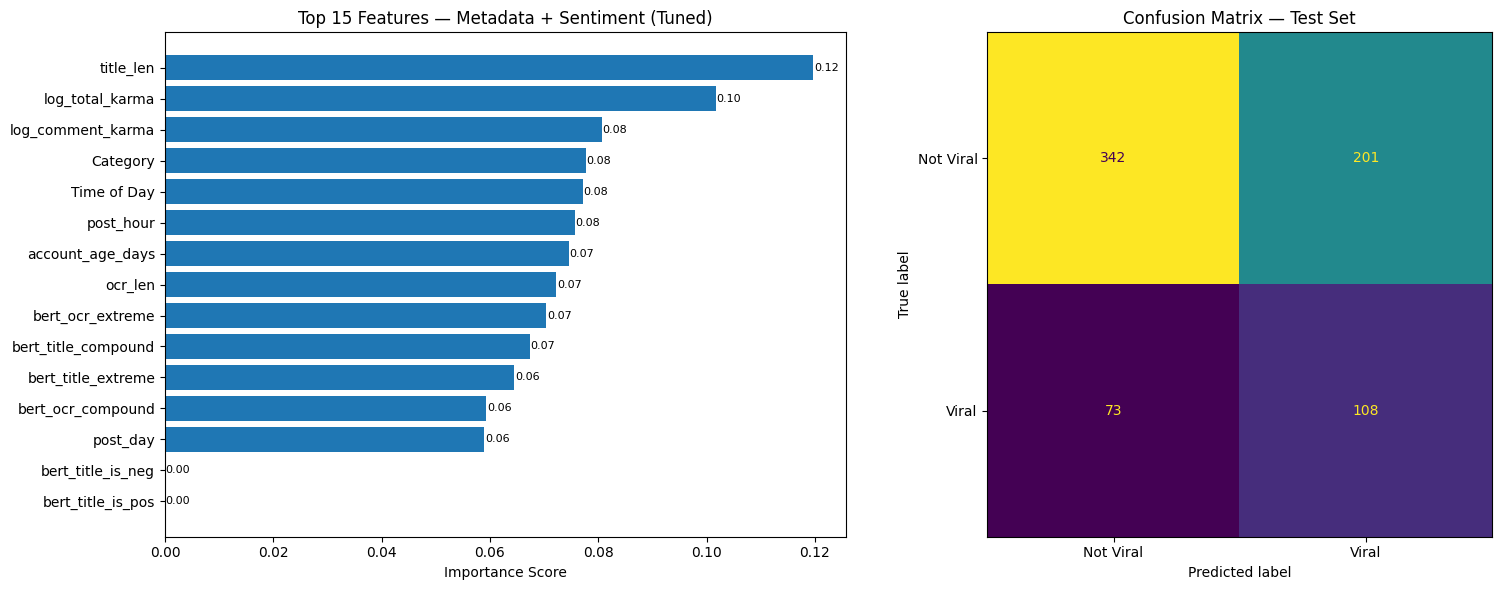

In [35]:
importance_df = pd.DataFrame({
    "feature"   : FEATURE_COLS,
    "importance": best_model.feature_importances_,
}).sort_values("importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance
top15 = importance_df.head(15)
axes[0].barh(top15["feature"][::-1], top15["importance"][::-1])
axes[0].set_xlabel("Importance Score")
axes[0].set_title("Top 15 Features — Metadata + Sentiment (Tuned)")
for i, v in enumerate(top15["importance"][::-1]):
    axes[0].text(v + 0.0001, i, f"{v:.2f}", va="center", fontsize=8)

# Confusion matrix
test_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Viral", "Viral"])
disp.plot(ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix — Test Set")

plt.tight_layout()
plt.show()

# Summary

In [33]:
rows = []
for model_name, model in [("Baseline", baseline), ("Tuned", best_model)]:
    for split_name, X, y in [("Train", X_train, y_train),
                               ("Val", X_val, y_val),
                               ("Test", X_test, y_test)]:
        preds = model.predict(X)
        probs = model.predict_proba(X)[:, 1]
        rows.append({
            "Model" : model_name,
            "Split" : split_name,
            "Accuracy": round(accuracy_score(y, preds), 4),
            "ROC-AUC" : round(roc_auc_score(y, probs),  4),
            "F1-macro": round(f1_score(y, preds, average="macro"), 4),
            "F1-viral": round(f1_score(y, preds, pos_label=1), 4),
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

   Model Split  Accuracy  ROC-AUC  F1-macro  F1-viral
Baseline Train    0.9905   0.9998    0.9875    0.9814
Baseline   Val    0.7040   0.6642    0.6057    0.4088
Baseline  Test    0.6920   0.6403    0.5688    0.3383
   Tuned Train    0.7774   0.8844    0.7463    0.6575
   Tuned   Val    0.6390   0.7012    0.5976    0.4684
   Tuned  Test    0.6215   0.6683    0.5774    0.4408
